# 06 — Cartogram & Area Correction
**Part 6 of 7** | GeoMetric Project

## Learning Objectives
- Show how standard geographic maps mislead through land-area bias
- Build a Dorling cartogram (circles sized by population)
- Articulate the "size vs data" effect with concrete examples

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
import warnings; warnings.filterwarnings("ignore")
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from scripts.utils.config import PATHS, STYLE
from scripts.utils.map_utils import reproject_gdf, save_figure, add_map_annotations, scale_symbols

In [2]:
world = gpd.read_file(PATHS["processed"] / "master_world.gpkg")

# Print the top/bottom countries by area vs emissions to illustrate the bias
top_area = world.nlargest(5, "area_km2")[["country_name","area_km2","co2_per_capita","pop_final"]]
top_emiss = world.dropna(subset=["co2_per_capita"]).nlargest(5, "co2_per_capita")[["country_name","area_km2","co2_per_capita","pop_final"]]
print("Top 5 by Land Area:")
print(top_area.to_string(index=False))
print("\nTop 5 by CO₂ per Capita:")
print(top_emiss.to_string(index=False))

Top 5 by Land Area:
            country_name     area_km2  co2_per_capita    pop_final
                  Russia 1.702059e+07          11.156  145245148.0
              Antarctica 1.233777e+07             NaN          NaN
                  Canada 1.003773e+07          13.795   38028638.0
United States of America 9.509851e+06          13.890  331577720.0
                   China 9.409565e+06           7.647 1411100000.0

Top 5 by CO₂ per Capita:
        country_name     area_km2  co2_per_capita  pop_final
               Qatar 11327.944169          36.564  2794148.0
              Brunei 10698.796949          24.937   447404.0
 Trinidad and Tobago  7738.923479          23.677  1366725.0
United Arab Emirates 80033.977064          23.007  9401038.0
              Kuwait 16632.269360          21.739  4400267.0


  🔄 Reprojected → robinson
  💾 Saved: map_standard_geographic.png  (300 DPI)


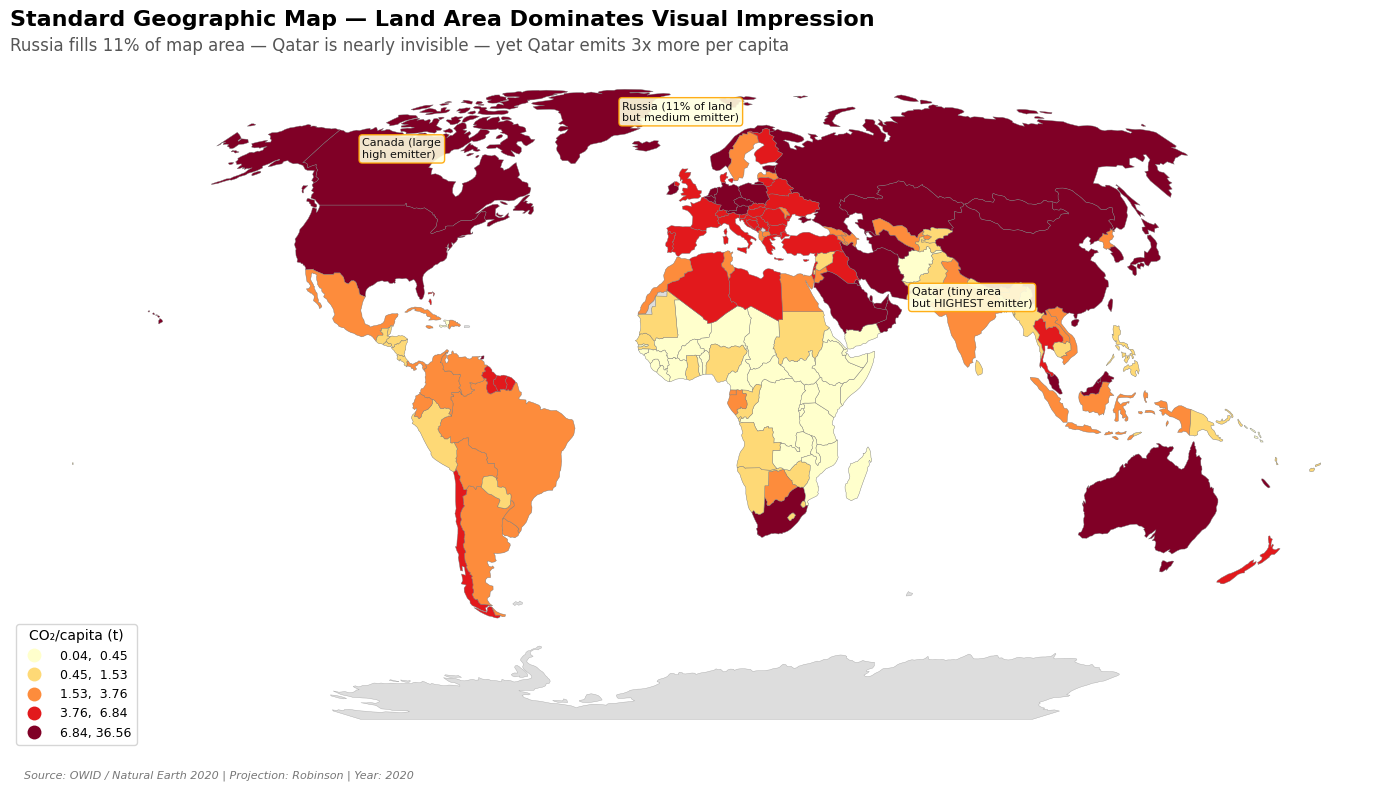

In [3]:
# ── Standard geographic map ─────────────────────────────────
world_proj = reproject_gdf(world.copy(), "robinson")

fig, ax = plt.subplots(figsize=(18, 9))
fig.patch.set_facecolor("white")
ax.set_facecolor(STYLE["ocean_color"])

world_proj[world_proj["co2_per_capita"].isna()].plot(ax=ax, color="#ddd", linewidth=0.3, edgecolor="#aaa")
world_proj.dropna(subset=["co2_per_capita"]).plot(
    column="co2_per_capita", ax=ax, scheme="Quantiles", k=5, cmap="YlOrRd",
    legend=True, legend_kwds={"title":"CO₂/capita (t)","loc":"lower left","fontsize":9},
    linewidth=0.3, edgecolor="#777", missing_kwds={"color":"#ddd"}
)

# Annotate the bias clearly
for txt, xy, iso in [
    ("Russia (11% of land\nbut medium emitter)", (-2e6, 7.5e6), "RUS"),
    ("Qatar (tiny area\nbut HIGHEST emitter)", (5.8e6, 2.5e6), "QAT"),
    ("Canada (large\nhigh emitter)", (-9e6, 6.5e6), "CAN"),
]:
    ax.annotate(txt, xy=xy, fontsize=8, color="#111",
                bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="orange", alpha=0.9))

ax.set_axis_off()
add_map_annotations(ax, title="Standard Geographic Map — Land Area Dominates Visual Impression",
                    subtitle="Russia fills 11% of map area — Qatar is nearly invisible — yet Qatar emits 3x more per capita",
                    source="OWID / Natural Earth 2020", projection_name="robinson", year=2020)
save_figure(fig, PATHS["fig_part6"] / "map_standard_geographic.png")
plt.show()

  🔄 Reprojected → robinson
  💾 Saved: map_dorling_cartogram.png  (300 DPI)


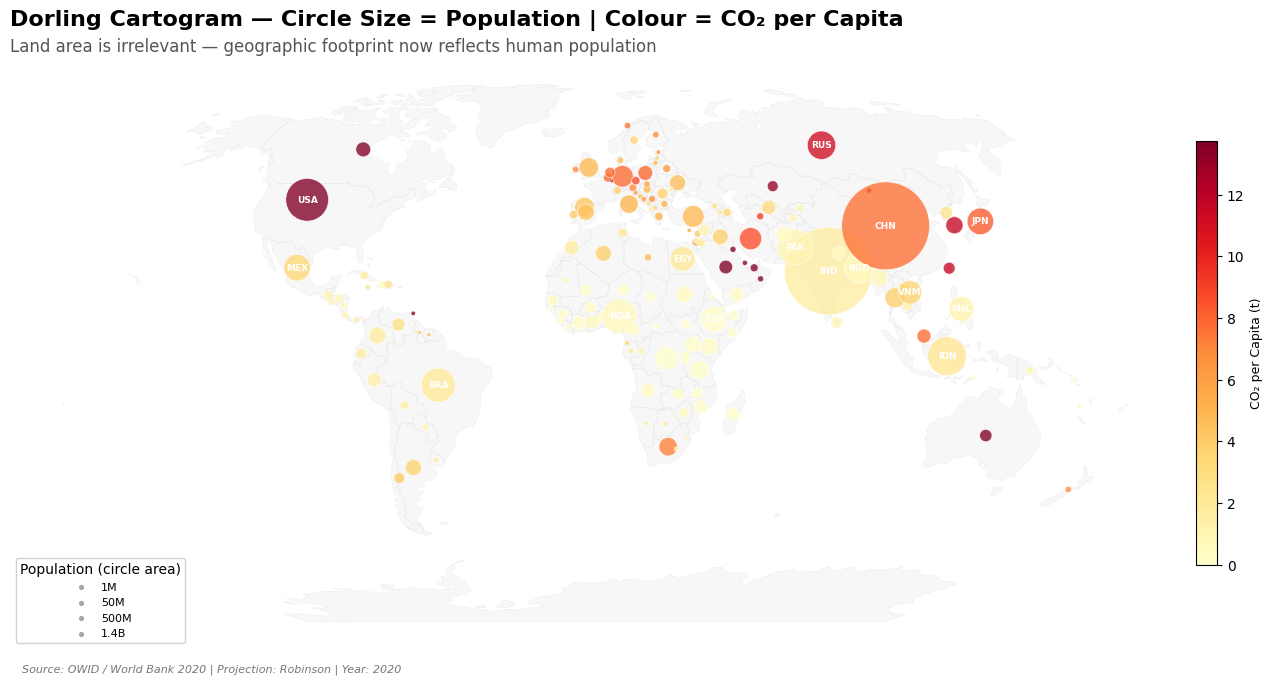

In [4]:
# ── Dorling Cartogram ───────────────────────────────────────
world_rob  = reproject_gdf(world.copy(), "robinson")
centroids  = world_rob.geometry.centroid
world_rob["cx"] = centroids.x
world_rob["cy"] = centroids.y
plot_df = world_rob.dropna(subset=["pop_final","co2_per_capita"]).copy()
plot_df = plot_df[plot_df["pop_final"] > 500_000]   # skip micro-states

sizes  = scale_symbols(plot_df["pop_final"], min_size=8, max_size=4000, method="area")
norm   = mcolors.Normalize(vmin=0, vmax=plot_df["co2_per_capita"].quantile(0.95))
cmap   = cm.get_cmap("YlOrRd")
colors = cmap(norm(plot_df["co2_per_capita"].values))

fig, ax = plt.subplots(figsize=(18, 10))
fig.patch.set_facecolor("white")
ax.set_facecolor("#e8f4f8")
world_rob.plot(ax=ax, color="#f0f0f0", linewidth=0.2, edgecolor="#cccccc", alpha=0.5)

sc = ax.scatter(plot_df["cx"], plot_df["cy"], s=sizes, c=colors,
                alpha=0.78, linewidths=0.5, edgecolors="white", zorder=5)

# Label top 15 by population
for _, row in plot_df.nlargest(15, "pop_final").iterrows():
    ax.annotate(row["iso_a3"], xy=(row["cx"], row["cy"]),
                fontsize=6.5, ha="center", va="center",
                color="white", fontweight="bold", zorder=10)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.55, pad=0.01)
cbar.set_label("CO₂ per Capita (t)", fontsize=9)

for ref_pop, label in [(1e6, "1M"), (50e6, "50M"), (500e6, "500M"), (1.4e9, "1.4B")]:
    rs = scale_symbols(pd.Series([ref_pop, plot_df["pop_final"].max()]), 8, 4000, "area")[0]
    ax.scatter([], [], s=rs, c="grey", alpha=0.6, label=label)
ax.legend(title="Population (circle area)", loc="lower left", fontsize=8, framealpha=0.85)
ax.set_axis_off()
add_map_annotations(ax, title="Dorling Cartogram — Circle Size = Population | Colour = CO₂ per Capita",
                    subtitle="Land area is irrelevant — geographic footprint now reflects human population",
                    source="OWID / World Bank 2020", projection_name="robinson", year=2020)
save_figure(fig, PATHS["fig_part6"] / "map_dorling_cartogram.png")
plt.show()

  💾 Saved: geographic_vs_cartogram_comparison.png  (300 DPI)


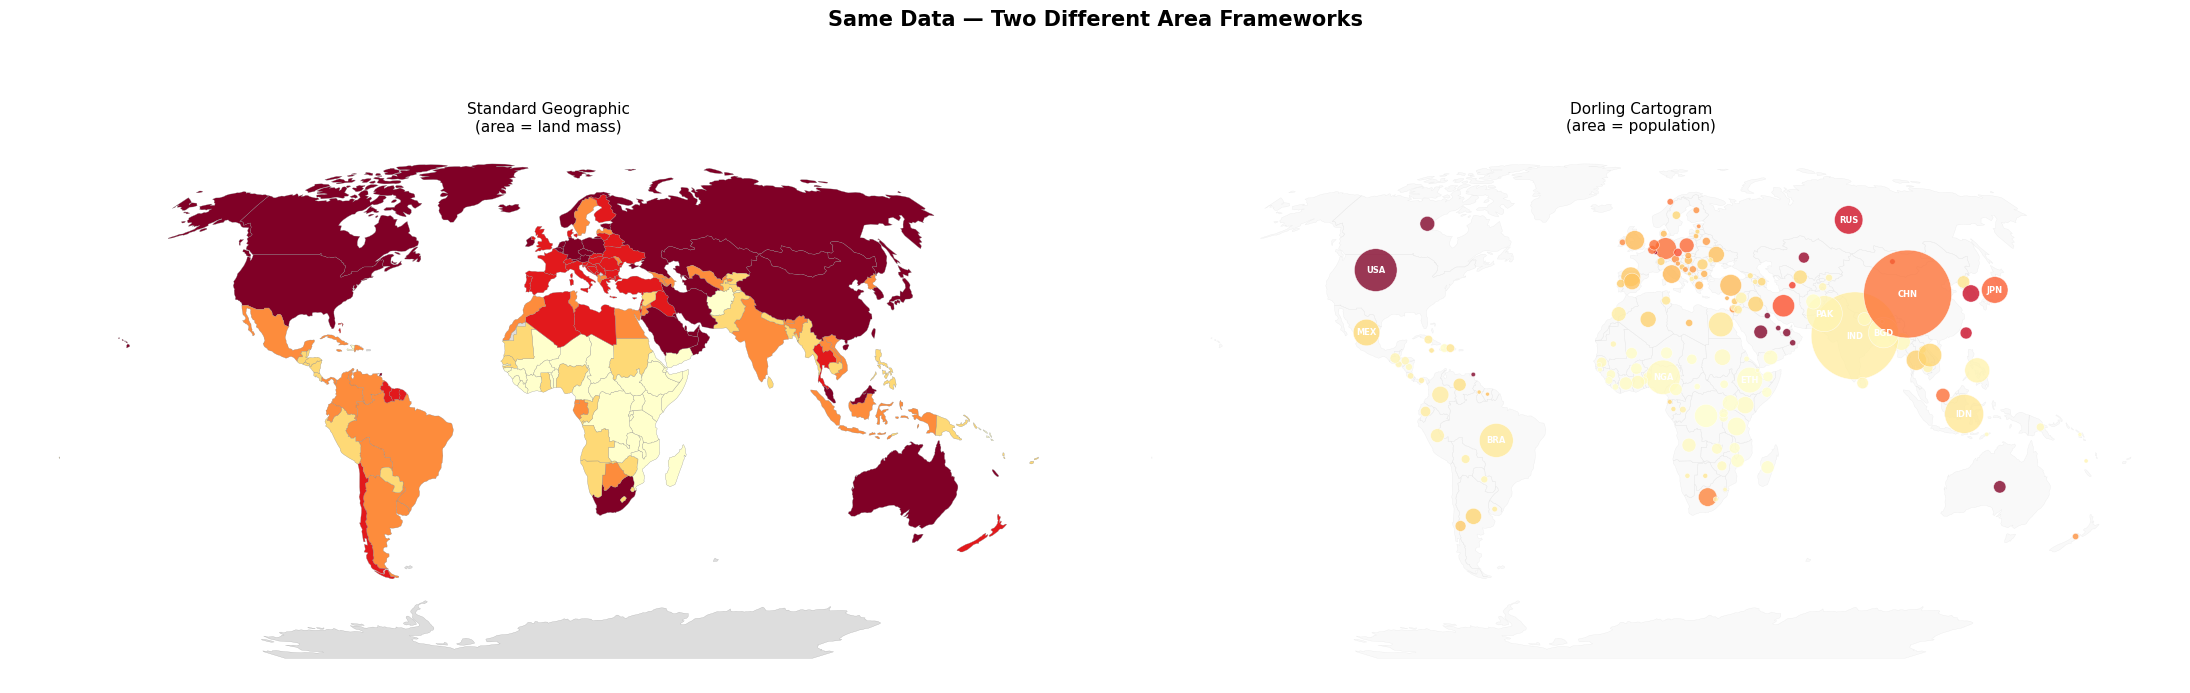

In [5]:
# ── Side-by-side comparison ────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))
fig.suptitle("Same Data — Two Different Area Frameworks", fontsize=15, fontweight="bold")

# Standard
world_proj[world_proj["co2_per_capita"].isna()].plot(ax=ax1, color="#ddd", linewidth=0.2, edgecolor="#aaa")
world_proj.dropna(subset=["co2_per_capita"]).plot(
    column="co2_per_capita", ax=ax1, scheme="Quantiles", k=5, cmap="YlOrRd",
    legend=False, linewidth=0.2, edgecolor="#888", missing_kwds={"color":"#ddd"}
)
ax1.set_axis_off(); ax1.set_facecolor(STYLE["ocean_color"])
ax1.set_title("Standard Geographic\n(area = land mass)", fontsize=11)

# Dorling
world_rob.plot(ax=ax2, color="#f0f0f0", linewidth=0.2, edgecolor="#ccc", alpha=0.4)
ax2.scatter(plot_df["cx"], plot_df["cy"], s=sizes, c=colors, alpha=0.78,
            edgecolors="white", linewidths=0.4, zorder=5)
for _, row in plot_df.nlargest(12, "pop_final").iterrows():
    ax2.annotate(row["iso_a3"], xy=(row["cx"], row["cy"]), fontsize=6,
                 ha="center", va="center", color="white", fontweight="bold", zorder=10)
ax2.set_axis_off(); ax2.set_facecolor("#e8f4f8")
ax2.set_title("Dorling Cartogram\n(area = population)", fontsize=11)

plt.tight_layout()
save_figure(fig, PATHS["fig_part6"] / "geographic_vs_cartogram_comparison.png")
plt.show()